# Grid Pathfinding Visualization & Benchmark Analysis

## Two-Stage Analysis Framework

This notebook implements a complete analysis pipeline for 5 grid pathfinding test cases:

- **Stage 1**: Visualize the smallest test (test_0.txt) with:
  - Grid display (obstacles, start, end)
  - Path comparison across algorithms
  - Performance metrics

- **Stage 2**: Aggregate and analyze benchmarks from remaining tests (test_1.txt → test_N.txt):
  - Path length performance (% difference from best)
  - Execution time analysis
  - Nodes expanded statistics

### Test Cases
- **blank**: Open grid with minimal obstacles
- **maze_loops**: Maze with loops and multiple paths
- **obstacles**: Scattered obstacles
- **dense**: High density of obstacles
- **perfect_maze**: Perfect maze structure

### Algorithms Tested
- DFS (Depth-First Search)
- BFS (Breadth-First Search)
- UCS (Uniform Cost Search)
- Greedy Best-First Search
- A* Search


## Setup and Configuration

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import pandas as pd
from pathlib import Path
import pickle
import json
from typing import Dict, List, Tuple
import time
from IPython.display import HTML, display

# Add src to path
src_path = Path.cwd().parent
sys.path.insert(0, str(src_path))

# Import custom modules
from utils.configHelper import load_config
from experiments.grid_experiment import GridExperiment
from problems.discrete import SPProblem
from utils.visualizes.grid_visualization import (
    load_trace, create_grid_animation, plot_path_comparison,
    plot_performance_comparison, plot_convergence_comparison, display_grid
)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)

print("✓ All libraries imported successfully")
print(f"✓ Working directory: {os.getcwd()}")

✓ All libraries imported successfully
✓ Working directory: D:\CODE\AI\AI1_search-algorithms\src\notebooks


In [2]:
# Configuration
TEST_CASES = {
    'blank': 'tests/SP/blank',
    'maze_loops': 'tests/SP/maze_loops',
    'obstacles': 'tests/SP/obstacles',
    'obstacles_dense': 'tests/SP/obstacles_dense',
    'perfect_maze': 'tests/SP/perfect_maze'
}

# Algorithms to test (excluding metaheuristics)
ALGORITHMS = ['DFS', 'BFS', 'GreedyBestFirst', 'AStarSearch', 'GA_Grid', 'ACO_Grid']
ALGORITHMS_DISPLAY = ['DFS', 'BFS/Uniform Cost', 'Greedy Best-First', 'A*', 'Genetic Algorithm', 'ACO']

# Output directory
OUTPUT_DIR = Path('outputs/grid_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Test cases: {list(TEST_CASES.keys())}")
print(f"Algorithms: {ALGORITHMS}")
print(f"Output directory: {OUTPUT_DIR}")

Test cases: ['blank', 'maze_loops', 'obstacles', 'obstacles_dense', 'perfect_maze']
Algorithms: ['DFS', 'BFS', 'GreedyBestFirst', 'AStarSearch', 'GA_Grid', 'ACO_Grid']
Output directory: outputs\grid_analysis


In [13]:
from pathlib import Path

# locate project root
PROJECT_ROOT = Path.cwd().parents[1]

# correct output folder
OUTPUT_DIR = PROJECT_ROOT / "src" / "outputs" / "grid_analysis"

print("Output directory:", OUTPUT_DIR)

Output directory: D:\CODE\AI\AI1_search-algorithms\src\outputs\grid_analysis


In [14]:
# Load and display benchmark results for each case
benchmark_results = {}

for case_name in TEST_CASES.keys():

    csv_path = OUTPUT_DIR / f"{case_name}_benchmark.csv"

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        benchmark_results[case_name] = df
        print(f"✓ Loaded {case_name}: {len(df)} results")

    else:
        print(f"✗ Benchmark CSV not found: {csv_path}")
        print(f"  Please run: python {OUTPUT_DIR}/prerun_{case_name}_benchmark.py")

✓ Loaded blank: 50 results
✓ Loaded maze_loops: 100 results
✓ Loaded obstacles: 100 results
✓ Loaded obstacles_dense: 100 results
✓ Loaded perfect_maze: 100 results


In [16]:
# Benchmark analysis functions

def analyze_path_length(df, case_name):
    """Analyze path length performance - % difference from best."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    grouped = df.groupby('algorithm')['best_fitness'].agg(['mean', 'std']).reset_index()
    best_path = grouped['mean'].min()
    grouped['pct_diff'] = ((grouped['mean'] - best_path) / best_path * 100).round(2)
    grouped = grouped.sort_values('pct_diff')
    
    colors = sns.color_palette("husl", len(grouped))
    bars = ax.barh(range(len(grouped)), grouped['pct_diff'], color=colors, alpha=0.8, edgecolor='black')
    
    for i, (idx, row) in enumerate(grouped.iterrows()):
        ax.text(row['pct_diff'] + 0.5, i, f"{row['pct_diff']:.1f}%", va='center', fontsize=10)
    
    ax.set_yticks(range(len(grouped)))
    ax.set_yticklabels(grouped['algorithm'])
    ax.set_xlabel('% Difference from Best Solution', fontsize=11, fontweight='bold')
    ax.set_title(f'Path Length Performance - {case_name}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def analyze_execution_time(df, case_name):
    """Analyze execution time across algorithms."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    time_stats = df.groupby('algorithm')['execution_time_seconds'].agg(['mean', 'std']).reset_index()
    time_stats = time_stats.sort_values('mean')
    
    colors = sns.color_palette("husl", len(time_stats))
    bars = axes[0].barh(range(len(time_stats)), time_stats['mean'], color=colors, alpha=0.8, edgecolor='black')
    axes[0].errorbar(time_stats['mean'], range(len(time_stats)), 
                     xerr=time_stats['std'], fmt='none', color='black', elinewidth=1, capsize=3)
    
    axes[0].set_yticks(range(len(time_stats)))
    axes[0].set_yticklabels(time_stats['algorithm'])
    axes[0].set_xlabel('Execution Time (seconds)', fontsize=11, fontweight='bold')
    axes[0].set_title('Mean Execution Time', fontsize=12, fontweight='bold')
    axes[0].set_xscale('log')
    axes[0].grid(axis='x', alpha=0.3)
    
    for algo in df['algorithm'].unique():
        algo_data = df[df['algorithm'] == algo]['execution_time_seconds']
        axes[1].hist(algo_data, bins=10, alpha=0.6, label=algo)
    
    axes[1].set_xlabel('Execution Time (seconds)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1].set_title('Distribution of Execution Times', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    fig.suptitle(f'Execution Time Analysis - {case_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def analyze_nodes_expanded(df, case_name):
    """Analyze nodes expanded across algorithms."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    nodes_stats = df.groupby('algorithm')['nodes_expanded'].agg(['mean', 'std']).reset_index()
    nodes_stats = nodes_stats.sort_values('mean', ascending=False)
    
    colors = sns.color_palette("husl", len(nodes_stats))
    bars = axes[0].barh(range(len(nodes_stats)), nodes_stats['mean'], color=colors, alpha=0.8, edgecolor='black')
    axes[0].errorbar(nodes_stats['mean'], range(len(nodes_stats)), 
                     xerr=nodes_stats['std'], fmt='none', color='black', elinewidth=1, capsize=3)
    
    axes[0].set_yticks(range(len(nodes_stats)))
    axes[0].set_yticklabels(nodes_stats['algorithm'])
    axes[0].set_xlabel('Nodes Expanded', fontsize=11, fontweight='bold')
    axes[0].set_title('Mean Nodes Expanded', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    plot_data = [df[df['algorithm'] == algo]['nodes_expanded'].values for algo in df['algorithm'].unique()]
    bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], sns.color_palette("husl", len(plot_data))):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    axes[1].set_ylabel('Nodes Expanded', fontsize=11, fontweight='bold')
    axes[1].set_title('Distribution of Nodes Expanded', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    fig.suptitle(f'Nodes Expanded Analysis - {case_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def print_summary_stats(df, case_name):
    """Print summary statistics table."""
    summary = df.groupby('algorithm').agg({
        'best_fitness': ['mean', 'std', 'min', 'max'],
        'nodes_expanded': ['mean', 'std'],
        'execution_time_seconds': ['mean', 'std']
    }).round(4)
    
    print(f"\n{case_name.upper()} Summary Statistics:")
    print(summary)

print("✓ Benchmark analysis functions loaded")

✓ Benchmark analysis functions loaded


## Stage 1: Visualization Analysis

### Blank Grid - Test Case 1

Loading blank case...
File path: D:\CODE\AI\AI1_search-algorithms\src\tests\SP\blank\test_0.txt
✓ Grid: 60 × 60
  Obstacles: 236


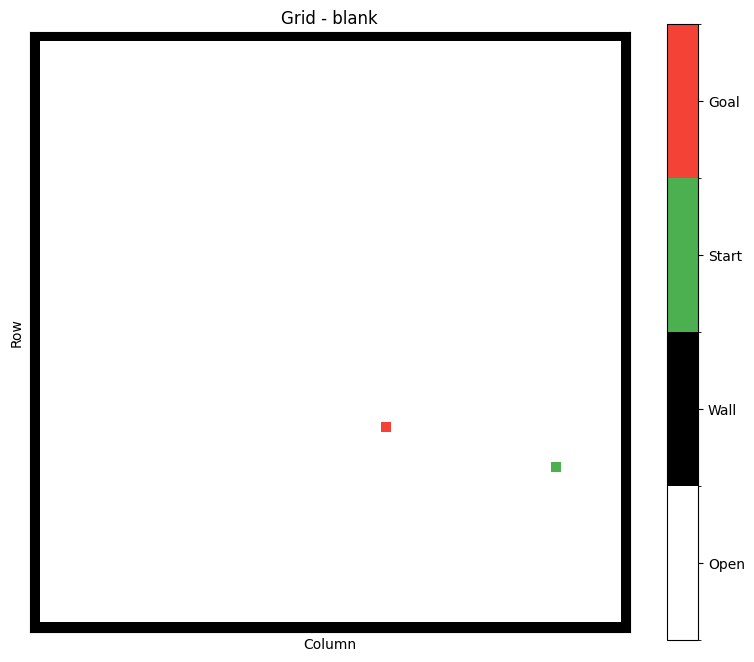

<Figure size 1400x1000 with 0 Axes>

In [3]:
from pathlib import Path
import numpy as np

# Define project root (AI1_search-algorithms)
PROJECT_ROOT = Path.cwd().parents[1]

# Load blank test_0.txt
case_name = 'blank'
test_file = PROJECT_ROOT / "src" / "tests" / "SP" / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

# Safety check
if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

# Save output
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)

start_time = time.time()
trace = experiment.visualize(ALGORITHMS, trace_path='blank_trace.pkl')
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f}s\n")
# print("Results:")
# for algo_name in ALGORITHMS:
#     if algo_name in trace['algorithms']:
#         result = trace['algorithms'][algo_name]
#         path_len = result.get('path_length', 'Failed')
#         nodes_exp = result.get('nodes_expanded', 'N/A')
#         time_t = result.get('execution_time_seconds', 'N/A')
#         print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

Running algorithms on blank...
Running visual experiment on 60x60 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Running GA_Grid...
  ✓ GA_Grid completed
Running ACO_Grid...
  ✓ ACO_Grid completed
Trace saved to: blank_trace.pkl
✓ Completed in 2.84s



In [5]:
%matplotlib inline
# Create animation for BFS, A*
print("Creating expansion animation for BFS...")
anim_bfs = create_grid_animation(trace, 'BFS', interval=20, save_path="outputs/bfs_blank.mp4")
anim_astar = create_grid_animation(trace, 'AStarSearch', interval=20, save_path="outputs/astar_blank.mp4")

Creating expansion animation for BFS...
Animation saved to: outputs/bfs_blank.mp4
Animation saved to: outputs/astar_blank.mp4


In [11]:
from IPython.display import Video

HTML("""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap:20px; width:700px">

<div>
<p style="text-align:center"><b>BFS/UCS</b></p>
<video width="320" controls>
  <source src="outputs/bfs_blank.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>A*</b></p>
<video width="320" controls>
  <source src="outputs/astar_blank.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>DFS</b></p>
<video width="320" controls>
  <source src="outputs/bfs_blank.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>Greedy Best-First Search</b></p>
<video width="320" controls>
  <source src="outputs/astar_blank.mp4" type="video/mp4">
</video>
</div>

</div>
""")

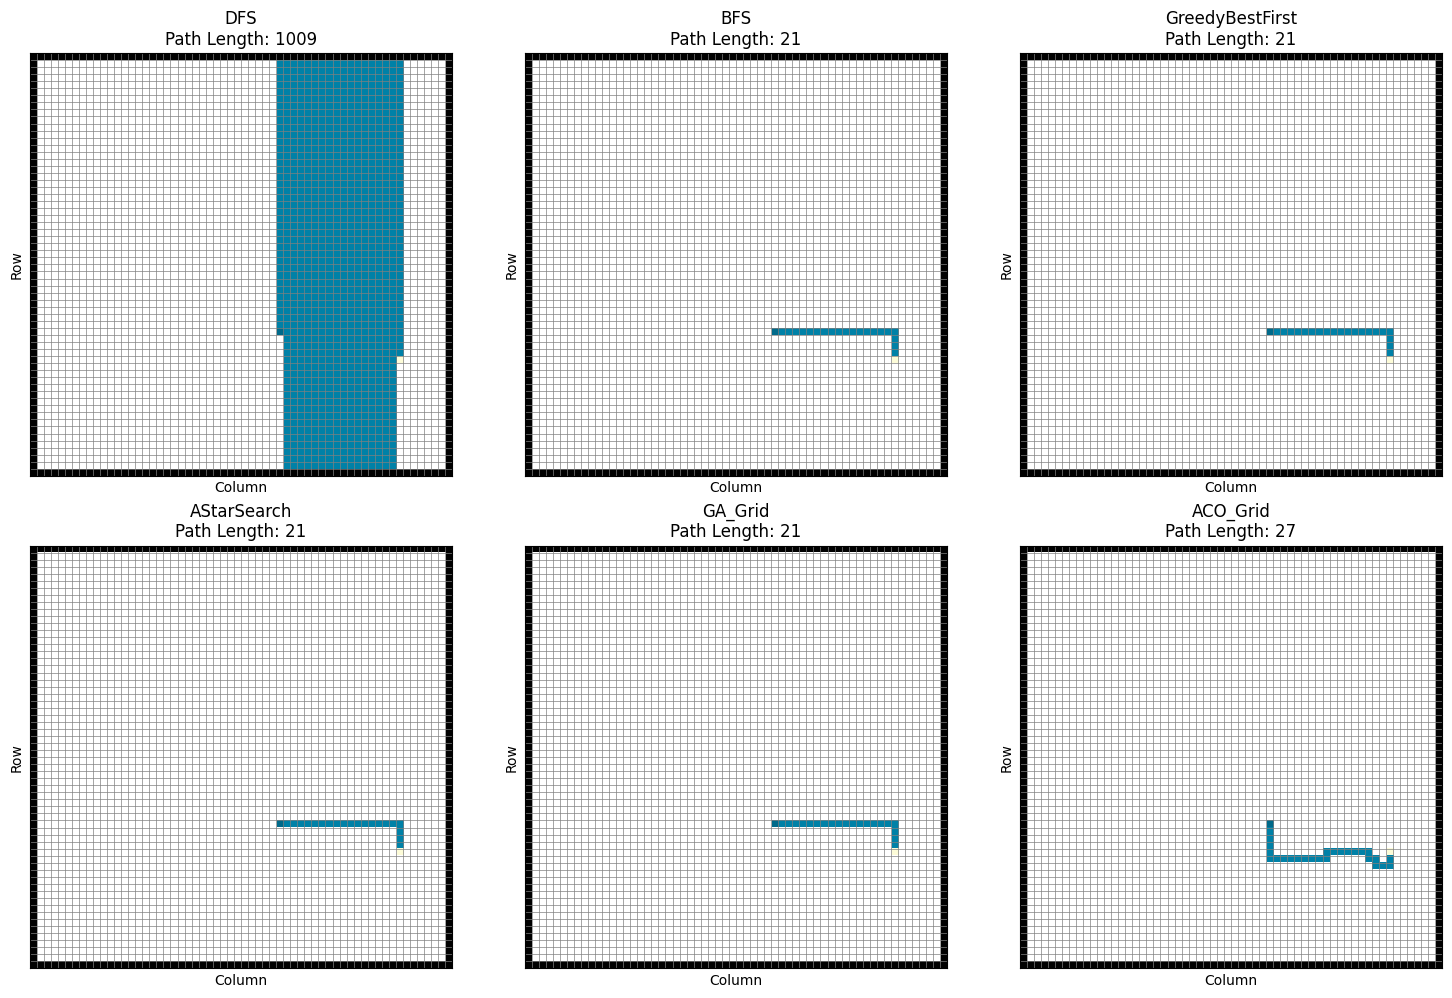

Saved trace to D:\CODE\AI\AI1_search-algorithms\outputs\blank_stage1_trace.pkl


In [7]:
# Path comparison
fig = plot_path_comparison(trace, ALGORITHMS)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Save trace
trace_file = OUTPUT_DIR / f'{case_name}_stage1_trace.pkl'
with open(trace_file, 'wb') as f:
    pickle.dump(trace, f)
print(f"Saved trace to {trace_file}")

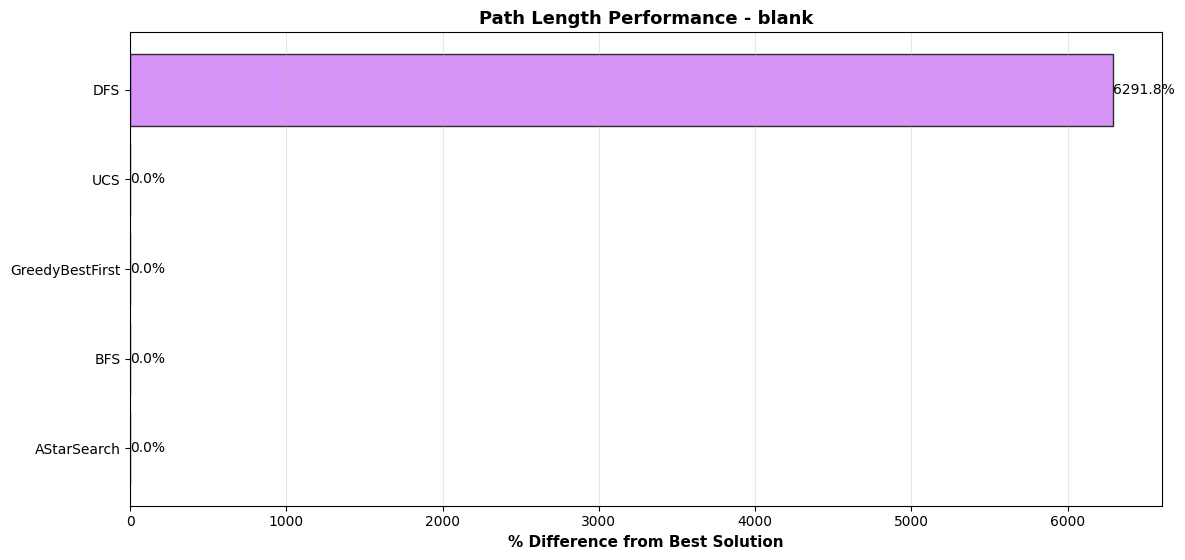

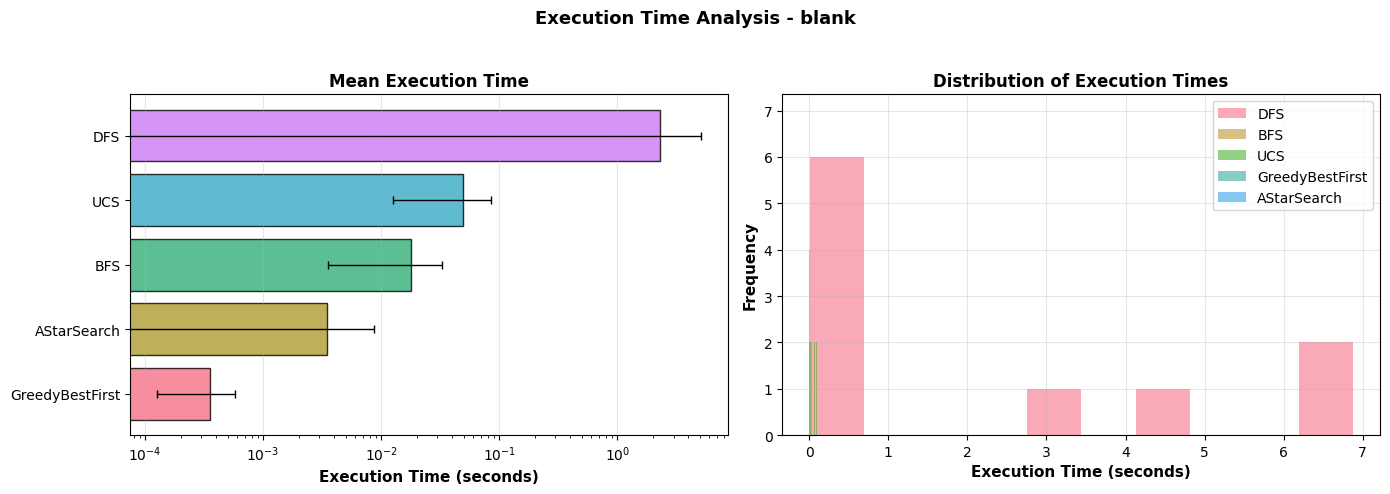

C:\Users\ngohu\AppData\Local\Temp\ipykernel_33920\3205350605.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)


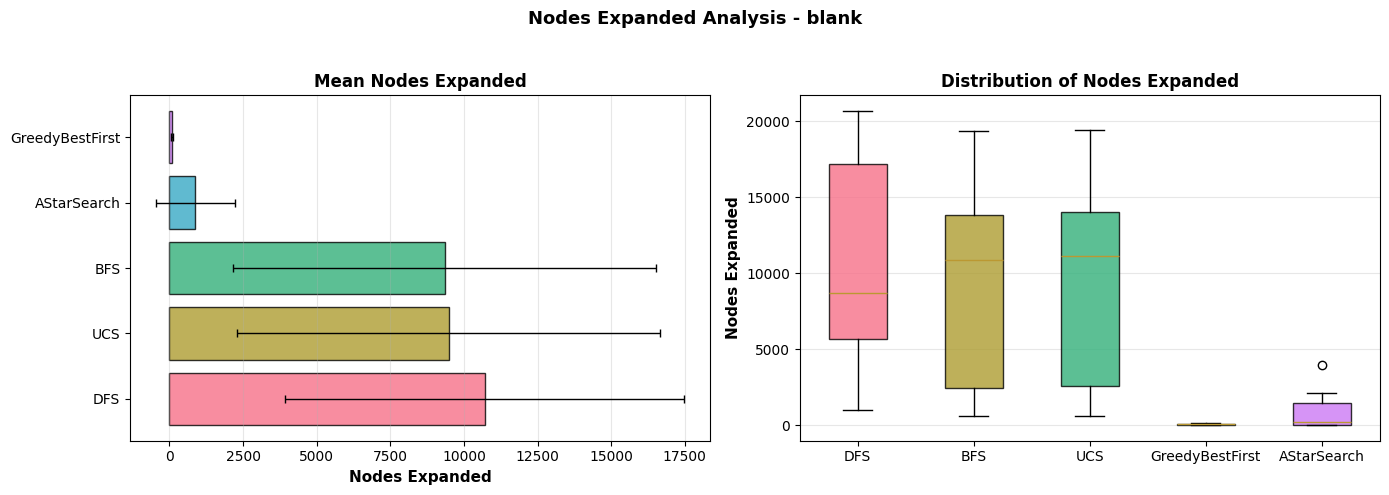


BLANK Summary Statistics:
                best_fitness                            nodes_expanded  \
                        mean        std    min      max           mean   
algorithm                                                                
AStarSearch             80.6    44.5376   21.0    134.0          885.2   
BFS                     80.6    44.5376   21.0    134.0         9342.1   
DFS                   5151.8  4429.1610  486.0  14626.0        10707.9   
GreedyBestFirst         80.6    44.5376   21.0    134.0           81.6   
UCS                     80.6    44.5376   21.0    134.0         9483.1   

                           execution_time_seconds          
                       std                   mean     std  
algorithm                                                  
AStarSearch      1324.9417                 0.0035  0.0052  
BFS              7172.5544                 0.0180  0.0145  
DFS              6768.5177                 2.3070  2.7975  
GreedyBestFirst    4

In [17]:
case_name = 'blank'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### maze_loops - Test Case 2

Loading maze_loops case...
File path: D:\CODE\AI\AI1_search-algorithms\src\tests\SP\maze_loops\test_0.txt
✓ Grid: 61 × 61
  Obstacles: 1894


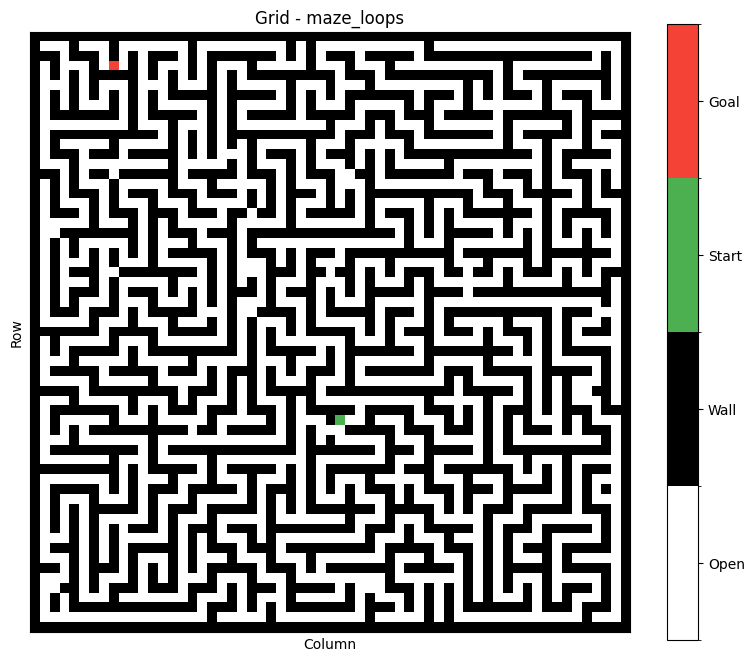

<Figure size 1400x1000 with 0 Axes>

In [8]:
from pathlib import Path
import numpy as np

# Define project root (AI1_search-algorithms)
PROJECT_ROOT = Path.cwd().parents[1]

# Load maze_loops test_0.txt
case_name = 'maze_loops'
test_file = PROJECT_ROOT / "src" / "tests" / "SP" / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

# Safety check
if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

# Ensure outputs directory exists
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

print(f"Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]
        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 'N/A')
        print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

fig = compare_paths(trace, ALGORITHMS, case_name)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

Running algorithms on maze_loops...
Running visual experiment on 61x61 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Running GA_Grid...
  ✓ GA_Grid completed
Running ACO_Grid...
  ✓ ACO_Grid completed
Results:
  DFS                  - Path:  362 | Nodes:    565 | Time: 0.0030s
  BFS                  - Path:  156 | Nodes:   1576 | Time: 0.0054s
  GreedyBestFirst      - Path:  158 | Nodes:    408 | Time: 0.0020s
  AStarSearch          - Path:  156 | Nodes:   1120 | Time: 0.0040s
  GA_Grid              - Path: Failed | Nodes: N/A    | Time: 0.0000s
  ACO_Grid             - Path: Failed | Nodes: N/A    | Time: 10.8402s


NameError: name 'compare_paths' is not defined

### obstacles - Test Case 3

In [ ]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load obstacles test
case_name = 'obstacles'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

# Print results
print("Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]
        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 0)

        print(f"{algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

# Compare paths
fig = compare_paths(trace, ALGORITHMS, case_name)

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

### dense - Test Case 4

In [ ]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load dense test
case_name = 'obstacles_dense'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

# Print results
print("Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]

        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 0)

        print(f"{algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

# Compare paths
fig = compare_paths(trace, ALGORITHMS, case_name)

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

### perfect_maze - Test Case 5

In [ ]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load perfect_maze test
case_name = 'perfect_maze'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

# Print results
print("Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]

        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 0)

        print(f"{algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

# Compare paths
fig = compare_paths(trace, ALGORITHMS, case_name)

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 2: Benchmark Analysis

### Instructions for Pre-Running Benchmarks

Before running Stage 2, you need to generate benchmark results for test_1.txt through test_N.txt.

**Option 1: Run Pre-Generated Scripts**
```bash
python outputs/grid_analysis/prerun_blank_benchmark.py
python outputs/grid_analysis/prerun_maze_loops_benchmark.py
python outputs/grid_analysis/prerun_obstacles_benchmark.py
python outputs/grid_analysis/prerun_dense_benchmark.py
python outputs/grid_analysis/prerun_perfect_maze_benchmark.py
```

**Option 2: Use the Standalone Python Script**
```bash
python grid_pathfinding_analysis.py
```


### blank - Benchmark Results

### maze_loops - Benchmark Results

In [ ]:
case_name = 'maze_loops'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### obstacles - Benchmark Results

In [ ]:
case_name = 'obstacles'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### dense - Benchmark Results

In [ ]:
case_name = 'obstacles_dense'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### perfect_maze - Benchmark Results

In [ ]:
case_name = 'perfect_maze'

if case_name in benchmark_results:
    df = benchmark_results[case_name]

    plt.figure(figsize=(10,6))
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,6))
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,6))
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()

    print_summary_stats(df, case_name)

else:
    print(f"Benchmark data not available for {case_name}")

## Cross-Case Comparison

Compare algorithm performance across all test cases

In [ ]:
# Combine all benchmark results
if benchmark_results:
    all_data = []
    for case_name, df in benchmark_results.items():
        df['case'] = case_name
        all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"Combined {len(benchmark_results)} test cases")
    print(f"Total results: {len(combined_df)}")
    
    # Plot comparison across cases
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Path length by case
    case_path_stats = combined_df.groupby(['case', 'algorithm'])['best_fitness'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_path_stats[case_path_stats['algorithm'] == algo]
        axes[0].plot(algo_data['case'], algo_data['best_fitness'], marker='o', label=algo)
    axes[0].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Mean Path Length', fontsize=11, fontweight='bold')
    axes[0].set_title('Path Length Across Test Cases', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Execution time by case
    case_time_stats = combined_df.groupby(['case', 'algorithm'])['execution_time_seconds'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_time_stats[case_time_stats['algorithm'] == algo]
        axes[1].plot(algo_data['case'], algo_data['execution_time_seconds'], marker='o', label=algo)
    axes[1].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean Execution Time (s)', fontsize=11, fontweight='bold')
    axes[1].set_title('Execution Time Across Test Cases', fontsize=12, fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Nodes expanded by case
    case_nodes_stats = combined_df.groupby(['case', 'algorithm'])['nodes_expanded'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_nodes_stats[case_nodes_stats['algorithm'] == algo]
        axes[2].plot(algo_data['case'], algo_data['nodes_expanded'], marker='o', label=algo)
    axes[2].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Mean Nodes Expanded', fontsize=11, fontweight='bold')
    axes[2].set_title('Nodes Expanded Across Test Cases', fontsize=12, fontweight='bold')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(OUTPUT_DIR / 'cross_case_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary

This analysis demonstrates:

### Stage 1: Visualization
- Grid structure and obstacle layout for each test case
- Path solutions from 5 different algorithms
- Solution quality and computational metrics

### Stage 2: Benchmark Analysis  
- Path length performance (% difference from best solution)
- Execution time comparison (mean and variance)
- Nodes expanded statistics (search efficiency)
- Cross-case comparison across all 5 test cases

### Key Insights
- **A* Search**: Typically finds optimal or near-optimal paths with efficient search
- **BFS**: Complete and optimal for unweighted graphs, moderate efficiency
- **Greedy Best-First**: Fast but may not find optimal solutions
- **UCS**: Optimal for weighted graphs, more expensive than BFS
- **DFS**: Generally inefficient for pathfinding, explores deeply before backtracking
